In [1]:
import pandas as pd
from mlxtend.frequent_patterns import association_rules
from mlxtend.frequent_patterns import apriori

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/sjsimmo2/DataMining-Fall/refs/heads/master/orderData.csv")

In [3]:
df.head()

,orderNo,seatNo,item
0,122314,1,Salmon
1,122314,1,Oyster Bay Sauvignon Blanc
2,122314,1,Bean Trio
3,122314,2,Pork Chop
4,122314,2,Three Rivers Red


In [4]:
df.shape

(228699, 3)

In [32]:
# drop the non-meat items from the df. They are outside the scope of this analysis:
items_list = df.item.unique().tolist()
items_list

['Salmon',
 'Oyster Bay Sauvignon Blanc',
 'Bean Trio',
 'Pork Chop',
 'Three Rivers Red',
 'Caesar Salad',
 'Sea Bass',
 'Total Recall Chardonnay',
 'Duck Breast',
 'Innocent Bystander Sauvignon Blanc',
 'Roasted Potatoes',
 'Swordfish',
 'Duckhorn Chardonnay',
 'Louis Rouge',
 'Roasted Root Veg',
 'Warm Goat Salad',
 'Pork Tenderloin',
 'Mashed Potatoes',
 'Helben Blanc',
 'Single Vineyard Malbec',
 'Seasonal Veg',
 'Adelsheim Pinot Noir',
 'Cantina Pinot Bianco',
 'Brancott Pinot Grigio',
 'Filet Mignon',
 'Blackstone Merlot',
 'Echeverria Gran Syrah',
 'Roast Chicken']

In [6]:
items_to_drop = ['Bean Trio','Caesar Salad','Roasted Potatoes','Roasted Root Veg', 'Warm Goat Salad', 'Mashed Potatoes', 'Seasonal Veg']

meat_and_wine_df = df[~df['item'].isin(items_to_drop)]

In [7]:
meat_and_wine_df.item.unique()

array(['Salmon', 'Oyster Bay Sauvignon Blanc', 'Pork Chop',
       'Three Rivers Red', 'Sea Bass', 'Total Recall Chardonnay',
       'Duck Breast', 'Innocent Bystander Sauvignon Blanc', 'Swordfish',
       'Duckhorn Chardonnay', 'Louis Rouge', 'Pork Tenderloin',
       'Helben Blanc', 'Single Vineyard Malbec', 'Adelsheim Pinot Noir',
       'Cantina Pinot Bianco', 'Brancott Pinot Grigio', 'Filet Mignon',
       'Blackstone Merlot', 'Echeverria Gran Syrah', 'Roast Chicken'],
      dtype=object)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
 [Text(0, 0, 'Salmon'),
  Text(1, 0, 'Oyster Bay Sauvignon Blanc'),
  Text(2, 0, 'Pork Chop'),
  Text(3, 0, 'Three Rivers Red'),
  Text(4, 0, 'Sea Bass'),
  Text(5, 0, 'Total Recall Chardonnay'),
  Text(6, 0, 'Duck Breast'),
  Text(7, 0, 'Innocent Bystander Sauvignon Blanc'),
  Text(8, 0, 'Swordfish'),
  Text(9, 0, 'Duckhorn Chardonnay'),
  Text(10, 0, 'Louis Rouge'),
  Text(11, 0, 'Pork Tenderloin'),
  Text(12, 0, 'Helben Blanc'),
  Text(13, 0, 'Single Vineyard Malbec'),
  Text(14, 0, 'Adelsheim Pinot Noir'),
  Text(15, 0, 'Cantina Pinot Bianco'),
  Text(16, 0, 'Brancott Pinot Grigio'),
  Text(17, 0, 'Filet Mignon'),
  Text(18, 0, 'Blackstone Merlot'),
  Text(19, 0, 'Echeverria Gran Syrah'),
  Text(20, 0, 'Roast Chicken')])

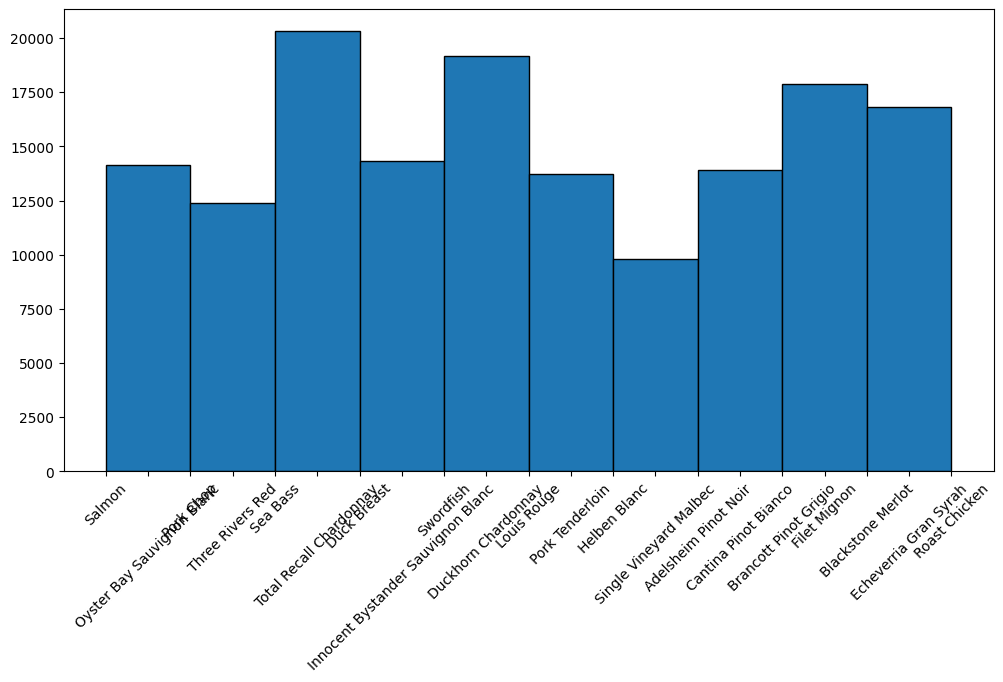

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.hist(meat_and_wine_df['item'], edgecolor='black')
plt.xticks(rotation=45)

In [8]:
# step one - get dummies for the items, and generate a true/false array
menu_1 = pd.get_dummies(meat_and_wine_df["item"])
menu_1.head()

,Adelsheim Pinot Noir,Blackstone Merlot,Brancott Pinot Grigio,Cantina Pinot Bianco,Duck Breast,Duckhorn Chardonnay,Echeverria Gran Syrah,Filet Mignon,Helben Blanc,Innocent Bystander Sauvignon Blanc,...,Oyster Bay Sauvignon Blanc,Pork Chop,Pork Tenderloin,Roast Chicken,Salmon,Sea Bass,Single Vineyard Malbec,Swordfish,Three Rivers Red,Total Recall Chardonnay
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
6,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [9]:
# step 2 - turn that array into a binary array
menu_2=menu_1*1
menu_2.head()

,Adelsheim Pinot Noir,Blackstone Merlot,Brancott Pinot Grigio,Cantina Pinot Bianco,Duck Breast,Duckhorn Chardonnay,Echeverria Gran Syrah,Filet Mignon,Helben Blanc,Innocent Bystander Sauvignon Blanc,...,Oyster Bay Sauvignon Blanc,Pork Chop,Pork Tenderloin,Roast Chicken,Salmon,Sea Bass,Single Vineyard Malbec,Swordfish,Three Rivers Red,Total Recall Chardonnay
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [10]:
# step 3 - create the unique order identifier. We will concatenate orderNo and seatNo for this
menu_2['id'] = df['orderNo'].astype(str) + df['seatNo'].astype(str)
menu_2.id.head()

0    1223141
1    1223141
3    1223142
4    1223142
6    1223143
Name: id, dtype: object

In [11]:
menu_2.head()

,Adelsheim Pinot Noir,Blackstone Merlot,Brancott Pinot Grigio,Cantina Pinot Bianco,Duck Breast,Duckhorn Chardonnay,Echeverria Gran Syrah,Filet Mignon,Helben Blanc,Innocent Bystander Sauvignon Blanc,...,Pork Chop,Pork Tenderloin,Roast Chicken,Salmon,Sea Bass,Single Vineyard Malbec,Swordfish,Three Rivers Red,Total Recall Chardonnay,id
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1223141
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1223141
3,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1223142
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1223142
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1223143


In [12]:
# step 4: aggregate the orders to 1 line per unique id, using max
menu_3 = menu_2.groupby(["id"]).max()
menu_3.head()

,Adelsheim Pinot Noir,Blackstone Merlot,Brancott Pinot Grigio,Cantina Pinot Bianco,Duck Breast,Duckhorn Chardonnay,Echeverria Gran Syrah,Filet Mignon,Helben Blanc,Innocent Bystander Sauvignon Blanc,...,Oyster Bay Sauvignon Blanc,Pork Chop,Pork Tenderloin,Roast Chicken,Salmon,Sea Bass,Single Vineyard Malbec,Swordfish,Three Rivers Red,Total Recall Chardonnay
id,,,,,,,,,,,,,,,,,,,,,
1223141,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0
1223142,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
1223143,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0
1223144,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
1223145,0,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [13]:
# step 5: apply a boolean filter that will turn values T/F, to confrom to the apriori library
menu_4=menu_3.applymap(bool)
menu_4.head()

/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T/ipykernel_34542/3348039081.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  menu_4=menu_3.applymap(bool)


,Adelsheim Pinot Noir,Blackstone Merlot,Brancott Pinot Grigio,Cantina Pinot Bianco,Duck Breast,Duckhorn Chardonnay,Echeverria Gran Syrah,Filet Mignon,Helben Blanc,Innocent Bystander Sauvignon Blanc,...,Oyster Bay Sauvignon Blanc,Pork Chop,Pork Tenderloin,Roast Chicken,Salmon,Sea Bass,Single Vineyard Malbec,Swordfish,Three Rivers Red,Total Recall Chardonnay
id,,,,,,,,,,,,,,,,,,,,,
1223141,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,True,False,False,False,False,False
1223142,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False
1223143,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
1223144,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
1223145,False,False,False,False,True,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [14]:
# step 6: get the support for each item in the dataset, cutting off at 0.01
menu_assoc = apriori(menu_4, min_support = 0.001, use_colnames = True)
menu_assoc

,support,itemsets
0,0.135217,(Adelsheim Pinot Noir)
1,0.111304,(Blackstone Merlot)
2,0.058741,(Brancott Pinot Grigio)
3,0.047145,(Cantina Pinot Bianco)
4,0.103826,(Duck Breast)
...,...,...
95,0.004854,"(Sea Bass, Three Rivers Red)"
96,0.015990,"(Sea Bass, Total Recall Chardonnay)"
97,0.002309,"(Single Vineyard Malbec, Swordfish)"
98,0.001928,"(Swordfish, Three Rivers Red)"


In [15]:
# create some outcome rules, by a threshold of conidence. We will set it to 0.1
out_rules = association_rules(menu_assoc,metric = "confidence", min_threshold = 0.1)
out_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(Duck Breast),(Adelsheim Pinot Noir),0.103826,0.135217,0.016476,0.158686,1.173565,0.002437,1.027896,0.165030
1,(Adelsheim Pinot Noir),(Duck Breast),0.135217,0.103826,0.016476,0.121847,1.173565,0.002437,1.020521,0.171021
2,(Filet Mignon),(Adelsheim Pinot Noir),0.175869,0.135217,0.049650,0.282315,2.087867,0.025870,1.204962,0.632232
3,(Adelsheim Pinot Noir),(Filet Mignon),0.135217,0.175869,0.049650,0.367191,2.087867,0.025870,1.302337,0.602512
4,(Adelsheim Pinot Noir),(Pork Chop),0.135217,0.143980,0.013826,0.102251,0.710175,-0.005642,0.953518,-0.320613
...,...,...,...,...,...,...,...,...,...,...
80,(Three Rivers Red),(Sea Bass),0.018601,0.161374,0.004854,0.260931,1.616936,0.001852,1.134706,0.388778
81,(Total Recall Chardonnay),(Sea Bass),0.105099,0.161374,0.015990,0.152147,0.942823,-0.000970,0.989117,-0.063466
82,(Three Rivers Red),(Swordfish),0.018601,0.097582,0.001928,0.103667,1.062355,0.000113,1.006788,0.059807
83,(Total Recall Chardonnay),(Swordfish),0.105099,0.097582,0.017447,0.166001,1.701136,0.007191,1.082037,0.460562


In [16]:
out_rules2=out_rules[['antecedents','consequents','support','confidence','lift']]

out_rules2

,antecedents,consequents,support,confidence,lift
0,(Duck Breast),(Adelsheim Pinot Noir),0.016476,0.158686,1.173565
1,(Adelsheim Pinot Noir),(Duck Breast),0.016476,0.121847,1.173565
2,(Filet Mignon),(Adelsheim Pinot Noir),0.049650,0.282315,2.087867
3,(Adelsheim Pinot Noir),(Filet Mignon),0.049650,0.367191,2.087867
4,(Adelsheim Pinot Noir),(Pork Chop),0.013826,0.102251,0.710175
...,...,...,...,...,...
80,(Three Rivers Red),(Sea Bass),0.004854,0.260931,1.616936
81,(Total Recall Chardonnay),(Sea Bass),0.015990,0.152147,0.942823
82,(Three Rivers Red),(Swordfish),0.001928,0.103667,1.062355
83,(Total Recall Chardonnay),(Swordfish),0.017447,0.166001,1.701136


In [17]:
out_rules2.sort_values(by='lift', ascending=False)

,antecedents,consequents,support,confidence,lift
58,(Louis Rouge),(Pork Chop),0.016555,0.489147,3.397336
57,(Pork Chop),(Louis Rouge),0.016555,0.114978,3.397336
9,(Filet Mignon),(Blackstone Merlot),0.062729,0.356679,3.204565
10,(Blackstone Merlot),(Filet Mignon),0.062729,0.563583,3.204565
62,(Roast Chicken),(Oyster Bay Sauvignon Blanc),0.009471,0.194086,3.072847
...,...,...,...,...,...
81,(Total Recall Chardonnay),(Sea Bass),0.015990,0.152147,0.942823
11,(Brancott Pinot Grigio),(Pork Chop),0.006965,0.118580,0.823587
35,(Roast Chicken),(Duckhorn Chardonnay),0.005982,0.122581,0.797124
4,(Adelsheim Pinot Noir),(Pork Chop),0.013826,0.102251,0.710175


In [20]:
mains = ['Salmon', 'Pork Chop','Sea Bass','Duck Breast', 'Swordfish','Pork Tenderloin','Filet Mignon','Roast Chicken']

In [21]:
# Convert the 'antecedents' column from sets to strings (if desired for visualization)
out_rules2['antecedents_str'] = out_rules2['antecedents'].apply(lambda x: ', '.join(list(x)))

# Filter rows where any of the items in the 'antecedents' set are in the 'mains' list
filt_antecedents = out_rules2[out_rules2['antecedents'].apply(lambda x: any(item in x for item in mains))]

print(filt_antecedents)


          antecedents                           consequents   support  \
0       (Duck Breast)                (Adelsheim Pinot Noir)  0.016476   
2      (Filet Mignon)                (Adelsheim Pinot Noir)  0.049650   
5   (Pork Tenderloin)                (Adelsheim Pinot Noir)  0.043734   
7       (Duck Breast)                   (Blackstone Merlot)  0.032886   
9      (Filet Mignon)                   (Blackstone Merlot)  0.062729   
12    (Roast Chicken)               (Brancott Pinot Grigio)  0.008448   
15         (Sea Bass)               (Brancott Pinot Grigio)  0.016856   
17        (Swordfish)               (Brancott Pinot Grigio)  0.014705   
22           (Salmon)                (Cantina Pinot Bianco)  0.013328   
30      (Duck Breast)              (Single Vineyard Malbec)  0.010533   
32        (Pork Chop)                 (Duckhorn Chardonnay)  0.033004   
34  (Pork Tenderloin)                 (Duckhorn Chardonnay)  0.035510   
35    (Roast Chicken)                 (Duckhorn Cha

/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T/ipykernel_34542/1142272067.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  out_rules2['antecedents_str'] = out_rules2['antecedents'].apply(lambda x: ', '.join(list(x)))


In [22]:
filt_antecedents

,antecedents,consequents,support,confidence,lift,antecedents_str
0,(Duck Breast),(Adelsheim Pinot Noir),0.016476,0.158686,1.173565,Duck Breast
2,(Filet Mignon),(Adelsheim Pinot Noir),0.049650,0.282315,2.087867,Filet Mignon
5,(Pork Tenderloin),(Adelsheim Pinot Noir),0.043734,0.299336,2.213742,Pork Tenderloin
7,(Duck Breast),(Blackstone Merlot),0.032886,0.316740,2.845736,Duck Breast
9,(Filet Mignon),(Blackstone Merlot),0.062729,0.356679,3.204565,Filet Mignon
12,(Roast Chicken),(Brancott Pinot Grigio),0.008448,0.173118,2.947147,Roast Chicken
15,(Sea Bass),(Brancott Pinot Grigio),0.016856,0.104455,1.778223,Sea Bass
17,(Swordfish),(Brancott Pinot Grigio),0.014705,0.150692,2.565370,Swordfish
22,(Salmon),(Cantina Pinot Bianco),0.013328,0.108826,2.308330,Salmon
30,(Duck Breast),(Single Vineyard Malbec),0.010533,0.101453,0.992692,Duck Breast


In [43]:
filt_antecedents.sort_values(by=['antecedents_str','support', 'confidence','lift'], ascending=False)

,antecedents,consequents,support,confidence,lift,antecedents_str
41,(Swordfish),(Duckhorn Chardonnay),0.017538,0.179728,1.168749,Swordfish
84,(Swordfish),(Total Recall Chardonnay),0.017447,0.178787,1.701136,Swordfish
17,(Swordfish),(Brancott Pinot Grigio),0.014705,0.150692,2.565370,Swordfish
66,(Swordfish),(Oyster Bay Sauvignon Blanc),0.013905,0.142492,2.255994,Swordfish
55,(Swordfish),(Innocent Bystander Sauvignon Blanc),0.013642,0.139804,1.666040,Swordfish
38,(Sea Bass),(Duckhorn Chardonnay),0.040232,0.249309,1.621221,Sea Bass
53,(Sea Bass),(Innocent Bystander Sauvignon Blanc),0.036651,0.227118,2.706558,Sea Bass
15,(Sea Bass),(Brancott Pinot Grigio),0.016856,0.104455,1.778223,Sea Bass
78,(Salmon),(Total Recall Chardonnay),0.021605,0.176414,1.678552,Salmon
63,(Salmon),(Oyster Bay Sauvignon Blanc),0.018365,0.149957,2.374181,Salmon


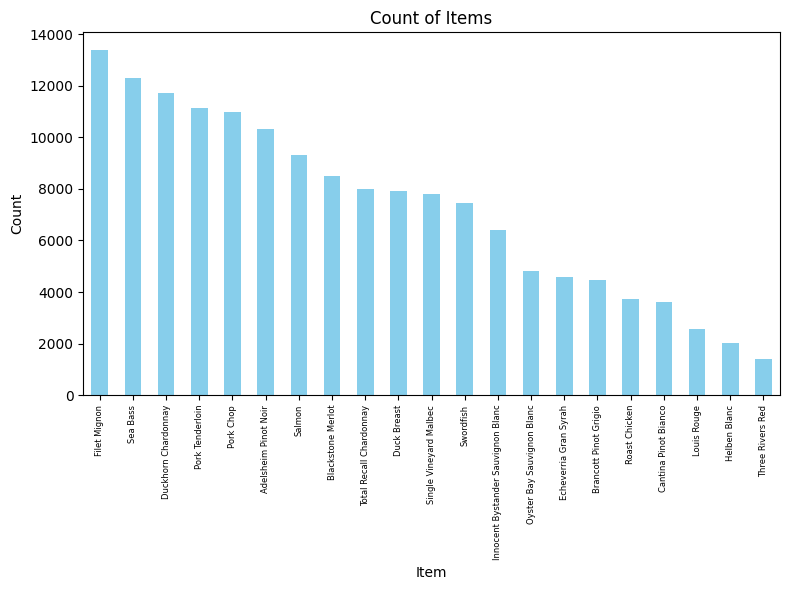

In [41]:
# Count occurrences of each unique item
item_counts = meat_and_wine_df['item'].value_counts()

# Plot the counts as a bar chart
plt.figure(figsize=(8, 6))
item_counts.plot(kind='bar', color='skyblue')

# Add labels and title
plt.xlabel('Item')
plt.ylabel('Count')
plt.title('Count of Items')

# Rotate x-axis labels if needed
plt.xticks(fontsize=6)

# Show the plot
plt.tight_layout()
plt.show()